#**EXPERIMENT-7** -Glass Dataset

**AIM:**
To construct and evaluate Support Vector Machine (SVM) classifiers using different SVM variants (SVC, NuSVC, LinearSVC) on the Glass dataset and obtain a generalized model through hyperparameter tuning.

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
glass_data = pd.read_csv('/content/drive/MyDrive/Datasets/glass_data.csv')
print("Shape:\n", glass_data.shape)
print("\nFirst 2 Rows:\n",glass_data.head(2))
print("\nDuplicated:", glass_data.duplicated().sum())
print("\nMissing Values:\n", glass_data.isna().sum())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape:
 (214, 11)

First 2 Rows:
    column_a  column_b  column_c  column_d  column_e  column_f  column_g  \
0         1   1.52101     13.64      4.49      1.10     71.78      0.06   
1         2   1.51761     13.89      3.60      1.36     72.73      0.48   

   column_h  column_i  column_j  column_k  
0      8.75       0.0       0.0         1  
1      7.83       0.0       0.0         1  

Duplicated: 0

Missing Values:
 column_a    0
column_b    0
column_c    0
column_d    0
column_e    0
column_f    0
column_g    0
column_h    0
column_i    0
column_j    0
column_k    0
dtype: int64


In [ ]:
glass_data = glass_data.drop_duplicates()
glass_data.shape

(214, 11)

**Feature-Label Separation:**
Target column in your dataset: column_k

X → chemical composition features

Y → type of glass (multi-class)

In [ ]:
X = glass_data.drop("column_k", axis=1)
Y = glass_data["column_k"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("\nFirst 2 Rows of Scaled X_train:\n")
print(pd.DataFrame(X_train[:2], columns=X.columns))
print("\nFirst 2 Rows of Scaled X_test:\n")
print(pd.DataFrame(X_test[:2], columns=X.columns))


First 2 Rows of Scaled X_train:

   column_a  column_b  column_c  column_d  column_e  column_f  column_g  \
0  1.537245 -0.642975 -1.705978 -1.941220 -0.501138  3.215401  3.989840   
1 -1.103758  1.182333  1.002367  0.766828 -1.979694 -1.104123 -0.684057   

   column_h  column_i  column_j  
0 -0.020071 -0.344535 -0.619243  
1  0.448282 -0.344535 -0.619243  

First 2 Rows of Scaled X_test:

   column_a  column_b  column_c  column_d  column_e  column_f  column_g  \
0  1.650663 -0.685348  1.194108  -1.94122  2.681864  0.263938 -0.882562   
1  1.018766  0.468507 -0.124113  -1.94122  0.669385  0.491948 -0.034403   

   column_h  column_i  column_j  
0  0.360466  0.704406 -0.619243  
1  1.728935 -0.344535 -0.619243  


**Model Comparison: SVC with Different Kernels**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10]
results = []
for kernel in kernels:
    for C in C_values:
        model = SVC( kernel=kernel,  C=C,  gamma='scale')
        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test)

        results.append([kernel,C,accuracy_score(Y_test, Y_pred),f1_score(Y_test, Y_pred, average='weighted')])
results_df = pd.DataFrame(
    results,
    columns=['Kernel','C','Accuracy','Weighted_F1']
)
print(results_df)

   Kernel     C  Accuracy  Weighted_F1
0  linear   0.1  0.906977     0.877326
1  linear   1.0  0.976744     0.977348
2  linear  10.0  0.930233     0.934559
3     rbf   0.1  0.790698     0.720768
4     rbf   1.0  0.930233     0.917077
5     rbf  10.0  0.953488     0.953982
6    poly   0.1  0.488372     0.362986
7    poly   1.0  0.674419     0.635341
8    poly  10.0  0.813953     0.783735


**Best Model Selection:**

After observing results, choose the kernel and C with highest accuracy.

In [ ]:
best_model = SVC(kernel='rbf', C=10)
best_model.fit(X_train, Y_train)
Y_pred = best_model.predict(X_test)

**Decision Boundary Visualization (2D using PCA)**

Since dataset has many features, we reduce to 2 dimensions using PCA for visualization.

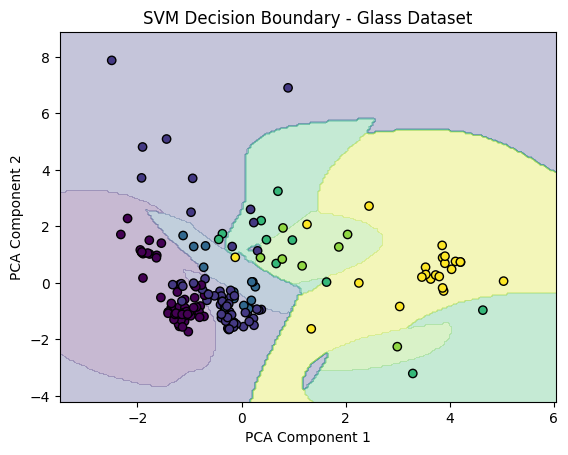

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
model_2d = SVC(kernel='rbf', C=10)
model_2d.fit(X_pca, Y_train)
x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=Y_train, edgecolor='k')
plt.title("SVM Decision Boundary - Glass Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

**Support Vectors**

Support vectors are the critical points that define the decision boundary.

In [ ]:
print("Number of Support Vectors:", model_2d.n_support_)

Number of Support Vectors: [17 34 14 10  7  8]


**Model Evaluation**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

Accuracy: 0.9534883720930233

Confusion Matrix:
 [[14  0  0  0  0  0]
 [ 0 14  0  0  1  0]
 [ 0  0  3  0  0  0]
 [ 0  0  0  3  0  0]
 [ 0  0  0  0  1  1]
 [ 0  0  0  0  0  6]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      0.93      0.97        15
           3       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       0.50      0.50      0.50         2
           7       0.86      1.00      0.92         6

    accuracy                           0.95        43
   macro avg       0.89      0.91      0.90        43
weighted avg       0.96      0.95      0.95        43

